# CW intrinsic frequency leakage

This notebook isolates the intrinsic frequency response of a monochromatic, Earth-term-only continuous wave (CW) in the ideal 25-pulsar PTA. The leakage kernel is the peak-normalised coherent frequency response

$$
K(f)=\frac{2\mathcal F(f)}{\max_f 2\mathcal F(f)}.
$$

The raw and timing-model-projected responses are compared with the exact sampling window and the finite-cadence Fejér reference. No sky search or stochastic statistic enters this calculation.

## 1. Configuration

In [1]:
from copy import deepcopy
from pathlib import Path
import sys

import astropy.units as u
import matplotlib.pyplot as plt
import numpy as np
from pint.logging import setup as setup_pint_logging
from pta_replicator.deterministic import add_cgw

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src" / "leakage").is_dir():
    PROJECT_ROOT = PROJECT_ROOT.parent
assert (PROJECT_ROOT / "src" / "leakage").is_dir(), "Run from the repository or notebooks directory"
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from leakage.datasets import load_pulsar
from leakage.cw_response import (
    DAY_S, apply_blocks, batch_coherent_profiles, coherent_statistic,
    exact_window_projection, fejer_power, four_amplitude_blocks,
    sample_times, timing_projectors,
)

setup_pint_logging(level="WARNING")
plt.rcParams.update({
    "figure.figsize": (7.2, 4.5),
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 10,
    "axes.labelsize": 10,
    "axes.titlesize": 11,
    "legend.fontsize": 9,
    "lines.linewidth": 1.6,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

IDEAL_DIR = PROJECT_ROOT / "data" / "baseline" / "ideal_25psr"
PRODUCT_DIR = PROJECT_ROOT / "data" / "products" / "leakage" / "ideal"
SCAN_PATH = PRODUCT_DIR / "leakage_scan.npz"
PRODUCT_DIR.mkdir(parents=True, exist_ok=True)

N_PSR = 25
SIGMA_S = 0.1e-6
SOURCE_RA = np.deg2rad(2.0)
SOURCE_DEC = np.deg2rad(0.4)
SOURCE_THETA = np.pi / 2 - SOURCE_DEC
SOURCE_PHI = SOURCE_RA
CHIRP_MASS = 1.0e9
DISTANCE_MPC = 100.0
POLARISATION = 0.0
INCLINATION = np.pi / 3
INITIAL_PHASE = 0.0

DELTA = np.round(np.linspace(0.0, 1.0, 101), 2)
TRIAL_K = np.round(np.arange(1.0, 10.0 + 0.005, 0.01), 2)

libstempo not installed. PINT or libstempo are required to use par and tim files.


## 2. Load ideal PTA

The canonical baseline contains 25 pulsars with a common regular cadence and $0.1\,\mu\mathrm{s}$ TOA uncertainty. Times and weights remain explicit so that later notebooks can replace the sampling model without changing the coherent response code.

In [2]:
parfiles = sorted((IDEAL_DIR / "par").glob("*.par"))
timfiles = sorted((IDEAL_DIR / "tim").glob("*.tim"))
assert len(parfiles) == len(timfiles) == N_PSR
assert [path.stem for path in parfiles] == [path.stem for path in timfiles]

ideal_psrs = [load_pulsar(par, tim) for par, tim in zip(parfiles, timfiles)]
tref_mjd = min(psr.toas.get_mjds().value.min() for psr in ideal_psrs)
times = sample_times(ideal_psrs, tref_mjd)
tspan = max(time.max() for time in times) - min(time.min() for time in times)
cadence_s = np.median(np.diff(times[0]))
fundamental = 1.0 / tspan
trial_frequencies = TRIAL_K * fundamental
injection_frequencies = (5.0 + DELTA) * fundamental

assert all(np.allclose(np.diff(time), cadence_s) for time in times)
print(f"Loaded {len(ideal_psrs)} pulsars; T = {tspan / DAY_S / 365.25:.3f} yr; cadence = {cadence_s / DAY_S:.1f} d")

Loaded 25 pulsars; T = 9.966 yr; cadence = 14.0 d


## 3. CW injection

Each injection is a monochromatic Earth term at the fixed source position. The pulsar term and binary evolution are disabled explicitly with `psrTerm=False` and `evolve=False`.

In [3]:
def inject_cw(frequency):
    psrs = deepcopy(ideal_psrs)
    for psr in psrs:
        add_cgw(
            psr=psr, gwtheta=SOURCE_THETA, gwphi=SOURCE_PHI,
            mc=CHIRP_MASS, dist=DISTANCE_MPC, fgw=frequency,
            phase0=INITIAL_PHASE, psi=POLARISATION, inc=INCLINATION,
            psrTerm=False, evolve=False, phase_approx=False,
            tref=tref_mjd * DAY_S, signal_name="cw",
        )
    return psrs


def signal_blocks(psrs):
    return [
        psr.added_signals_time[f"{psr.name}_cw"].to_value(u.s)
        for psr in psrs
    ]

## 4. Coherent CW model

At a fixed sky position and trial frequency, four basis columns span the two quadratures of the plus and cross antenna responses. Profiling their amplitudes gives the coherent statistic $2\mathcal F=\Delta\chi^2$. A single $f_{\rm CW}T=5.5$ reconstruction checks that this basis reproduces the injected Earth term.

In [4]:
representative_frequency = 5.5 * fundamental
representative_data = signal_blocks(inject_cw(representative_frequency))
representative_templates = four_amplitude_blocks(
    ideal_psrs, times, representative_frequency, SOURCE_THETA, SOURCE_PHI
)
_, _, recovered_amplitudes = coherent_statistic(
    representative_data, representative_templates, SIGMA_S
)
reconstructed = [template @ recovered_amplitudes for template in representative_templates]
reconstruction_error = (
    np.linalg.norm(np.concatenate(representative_data) - np.concatenate(reconstructed))
    / np.linalg.norm(np.concatenate(representative_data))
)
assert reconstruction_error < 1e-10

## 5. Timing-model projection

The post-fit calculation applies each pulsar's weighted linear timing-model projector to both the injected residuals and the trial templates. The raw response omits this projection.

In [5]:
projectors, projection_diagnostics = timing_projectors(ideal_psrs, SIGMA_S)
assert projection_diagnostics.idempotence_error < 1e-10
assert projection_diagnostics.orthogonality_error < 1e-10

## 6. Compute frequency leakage

For $f_{\rm CW}T=5+\delta$ with $\delta\in[0,1]$, the same trial-frequency bank is evaluated for the raw and post-fit data. Each row is normalised independently to form $K(f)$. The exact window includes both positive- and negative-frequency terms; the Fejér curve is the regular finite-cadence reference. Because every ideal pulsar shares the same epochs, one representative pulsar supplies the sampling-window comparison.

In [6]:
raw_data = [signal_blocks(inject_cw(frequency)) for frequency in injection_frequencies]
postfit_data = [apply_blocks(blocks, projectors) for blocks in raw_data]

raw_two_f, _ = batch_coherent_profiles(
    ideal_psrs, times, raw_data, trial_frequencies,
    SOURCE_THETA, SOURCE_PHI, SIGMA_S,
)
postfit_two_f, _ = batch_coherent_profiles(
    ideal_psrs, times, postfit_data, trial_frequencies,
    SOURCE_THETA, SOURCE_PHI, SIGMA_S, operators=projectors,
)

exact_sampling_power = np.empty_like(raw_two_f)
fejer_reference = np.empty_like(raw_two_f)
monochromatic_errors = np.empty(len(DELTA))
window_errors = np.empty(len(DELTA))
for row, (frequency, blocks) in enumerate(zip(injection_frequencies, raw_data)):
    _, exact, mono_error, window_error = exact_window_projection(
        blocks[0], times[0], trial_frequencies, frequency
    )
    exact_sampling_power[row] = exact
    fejer_reference[row] = fejer_power(
        len(times[0]), cadence_s, trial_frequencies - frequency
    )
    monochromatic_errors[row] = mono_error
    window_errors[row] = window_error

raw_kernel = raw_two_f / raw_two_f.max(axis=1, keepdims=True)
postfit_kernel = postfit_two_f / postfit_two_f.max(axis=1, keepdims=True)
sampling_kernel = exact_sampling_power / exact_sampling_power.max(axis=1, keepdims=True)
fejer_kernel = fejer_reference / fejer_reference.max(axis=1, keepdims=True)

assert monochromatic_errors.max() < 1e-10
assert window_errors.max() < 1e-12
assert TRIAL_K[np.argmax(raw_two_f[0])] == 5.0
assert TRIAL_K[np.argmax(raw_two_f[-1])] == 6.0
assert np.allclose(raw_kernel.max(axis=1), 1.0)
assert np.allclose(postfit_kernel.max(axis=1), 1.0)

np.savez_compressed(
    SCAN_PATH, format_version=np.array(1), n_psr=np.array(N_PSR),
    sigma_s=np.array(SIGMA_S), tspan=np.array(tspan), cadence_s=np.array(cadence_s),
    source_theta=np.array(SOURCE_THETA), source_phi=np.array(SOURCE_PHI),
    delta=DELTA, injection_frequencies=injection_frequencies,
    trial_k=TRIAL_K, trial_frequencies=trial_frequencies,
    raw_two_f=raw_two_f, postfit_two_f=postfit_two_f,
    raw_kernel=raw_kernel, postfit_kernel=postfit_kernel,
    exact_sampling_power=exact_sampling_power, sampling_kernel=sampling_kernel,
    fejer_reference=fejer_reference, fejer_kernel=fejer_kernel,
    reconstruction_error=np.array(reconstruction_error),
    projector_idempotence_error=np.array(projection_diagnostics.idempotence_error),
    monochromatic_errors=monochromatic_errors, window_errors=window_errors,
)

## 7. One-dimensional leakage figure

The representative $f_{\rm CW}T=5.5$ slice compares four independently peak-normalised responses. A logarithmic scale exposes the sidelobes without changing the leakage definition.

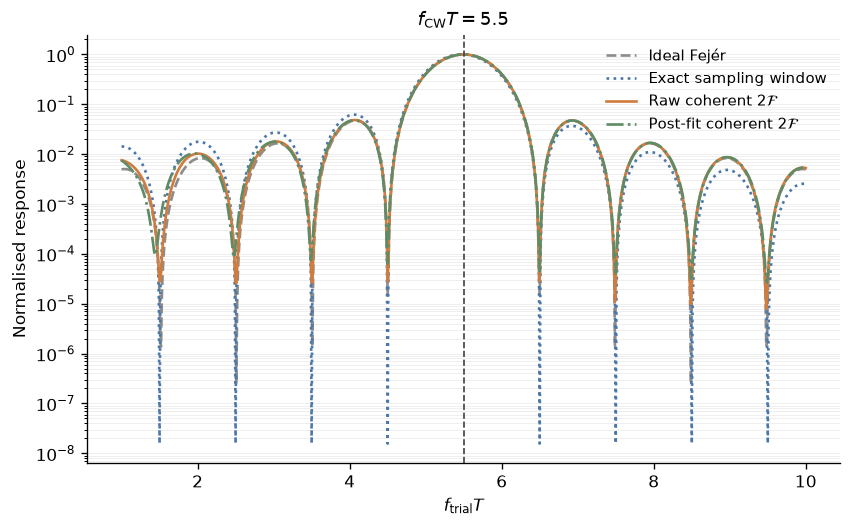

In [7]:
middle = np.flatnonzero(DELTA == 0.5)[0]
display_floor = 1e-10
fig, ax = plt.subplots()
ax.semilogy(TRIAL_K, np.maximum(fejer_kernel[middle], display_floor),
            color="0.55", linestyle="--", label="Ideal Fejér")
ax.semilogy(TRIAL_K, np.maximum(sampling_kernel[middle], display_floor),
            color="#4C78A8", linestyle=":", label="Exact sampling window")
ax.semilogy(TRIAL_K, np.maximum(raw_kernel[middle], display_floor),
            color="#D07C3E", label=r"Raw coherent $2\mathcal{F}$")
ax.semilogy(TRIAL_K, np.maximum(postfit_kernel[middle], display_floor),
            color="#5F8C67", linestyle="-.", label=r"Post-fit coherent $2\mathcal{F}$")
ax.axvline(5.5, color="0.25", linewidth=1.0, linestyle="--")
ax.set(
    xlabel=r"$f_{\mathrm{trial}}T$",
    ylabel="Normalised response",
    title=r"$f_{\mathrm{CW}}T=5.5$",
)
ax.grid(axis="y", which="both", color="0.85", linewidth=0.5, alpha=0.5)
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(PRODUCT_DIR / "leakage_1d_f5p5.pdf", bbox_inches="tight")
fig.savefig(PRODUCT_DIR / "leakage_1d_f5p5.png", dpi=300, bbox_inches="tight")
plt.show()

## 8. Two-dimensional leakage kernel figure

The raw coherent kernel is the closest measure of the intrinsic finite-window response, so it is the single 2D quantity shown here. The dashed line marks the injected frequency $f_{\rm CW}T=5+\delta$.

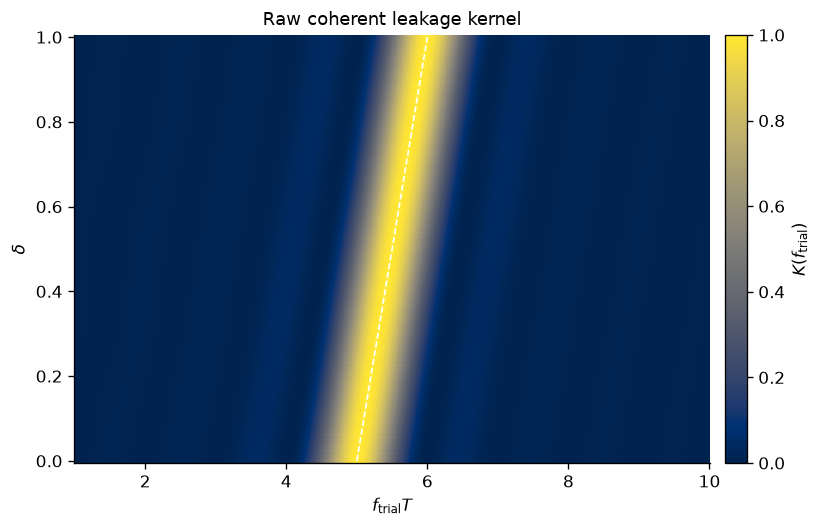

In [8]:
fig, ax = plt.subplots()
image = ax.pcolormesh(
    TRIAL_K, DELTA, raw_kernel, shading="auto",
    cmap="cividis", vmin=0.0, vmax=1.0,
)
ax.plot(5.0 + DELTA, DELTA, color="white", linestyle="--", linewidth=1.0)
ax.set(
    xlabel=r"$f_{\mathrm{trial}}T$",
    ylabel=r"$\delta$",
    title="Raw coherent leakage kernel",
)
colorbar = fig.colorbar(image, ax=ax, pad=0.02)
colorbar.set_label(r"$K(f_{\mathrm{trial}})$")
fig.tight_layout()
fig.savefig(PRODUCT_DIR / "leakage_kernel_2d.pdf", bbox_inches="tight")
fig.savefig(PRODUCT_DIR / "leakage_kernel_2d.png", dpi=300, bbox_inches="tight")
plt.show()

## 9. Short numerical summary

These values record only the checks needed to interpret and reproduce the leakage calculation.

In [9]:
middle_raw_peak = TRIAL_K[np.argmax(raw_kernel[middle])]
middle_postfit_peak = TRIAL_K[np.argmax(postfit_kernel[middle])]
raw_postfit_difference = np.max(np.abs(raw_kernel - postfit_kernel))
print(f"PTA: {N_PSR} pulsars, {sum(map(len, times))} TOAs, T = {tspan / DAY_S / 365.25:.3f} yr")
print(f"Four-amplitude reconstruction error: {reconstruction_error:.3e}")
print(f"Timing-projector idempotence error: {projection_diagnostics.idempotence_error:.3e}")
print(f"Maximum exact-window error: {window_errors.max():.3e}")
print(f"Peak at f_CW T = 5.5: raw {middle_raw_peak:.2f}, post-fit {middle_postfit_peak:.2f}")
print(f"Maximum |K_raw - K_post-fit|: {raw_postfit_difference:.3e}")
print(f"Saved scan and figures to {PRODUCT_DIR.relative_to(PROJECT_ROOT)}")

PTA: 25 pulsars, 6525 TOAs, T = 9.966 yr
Four-amplitude reconstruction error: 3.030e-14
Timing-projector idempotence error: 7.143e-15
Maximum exact-window error: 4.024e-15
Peak at f_CW T = 5.5: raw 5.50, post-fit 5.50
Maximum |K_raw - K_post-fit|: 5.095e-03
Saved scan and figures to data/products/leakage/ideal
